Using device: cuda

LOADING CIFAR-10 DATASET


100%|██████████| 170M/170M [44:14<00:00, 64.2kB/s]


Training samples: 40000
Validation samples: 10000
Test samples: 10000

Visualizing sample images...


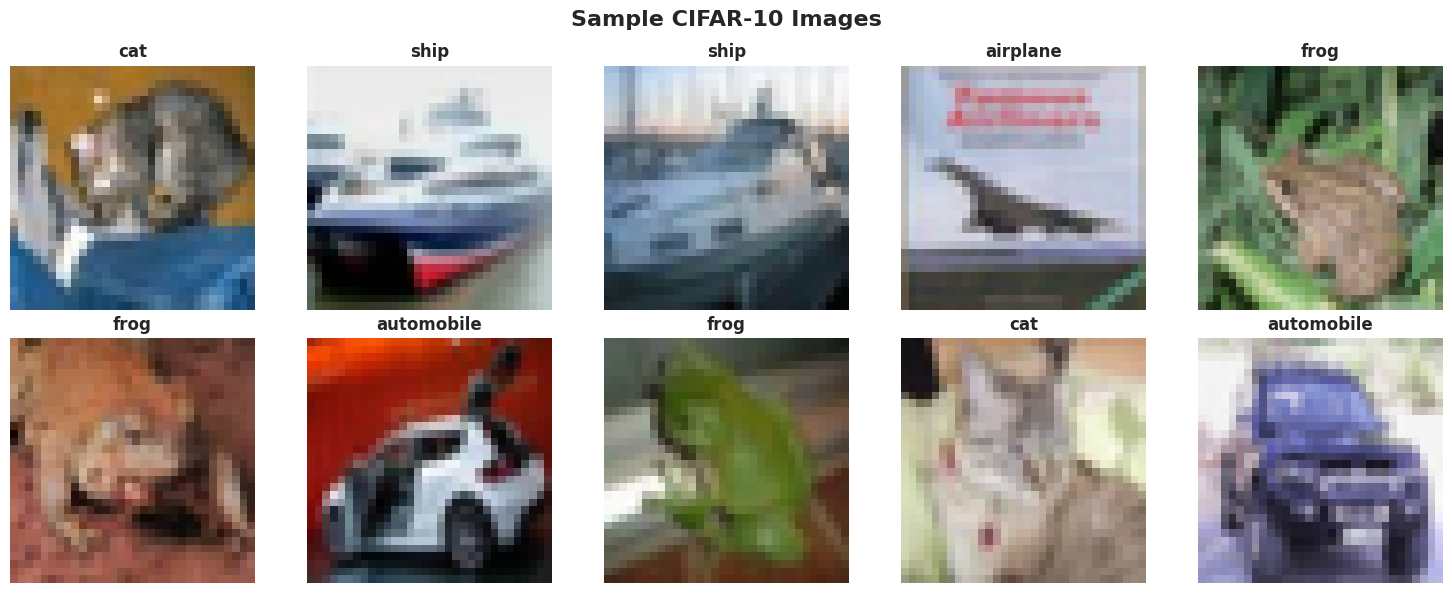

✅ Sample images displayed!

CREATING DATA LOADERS
Batch size: 64
Training batches: 625
Validation batches: 157
Test batches: 157

DEFINING CNN ARCHITECTURE

Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
         Dropout2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
      BatchNorm2d-10           [-1, 64, 16, 16]             128
             ReLU-11           [-1, 64, 16, 16]            

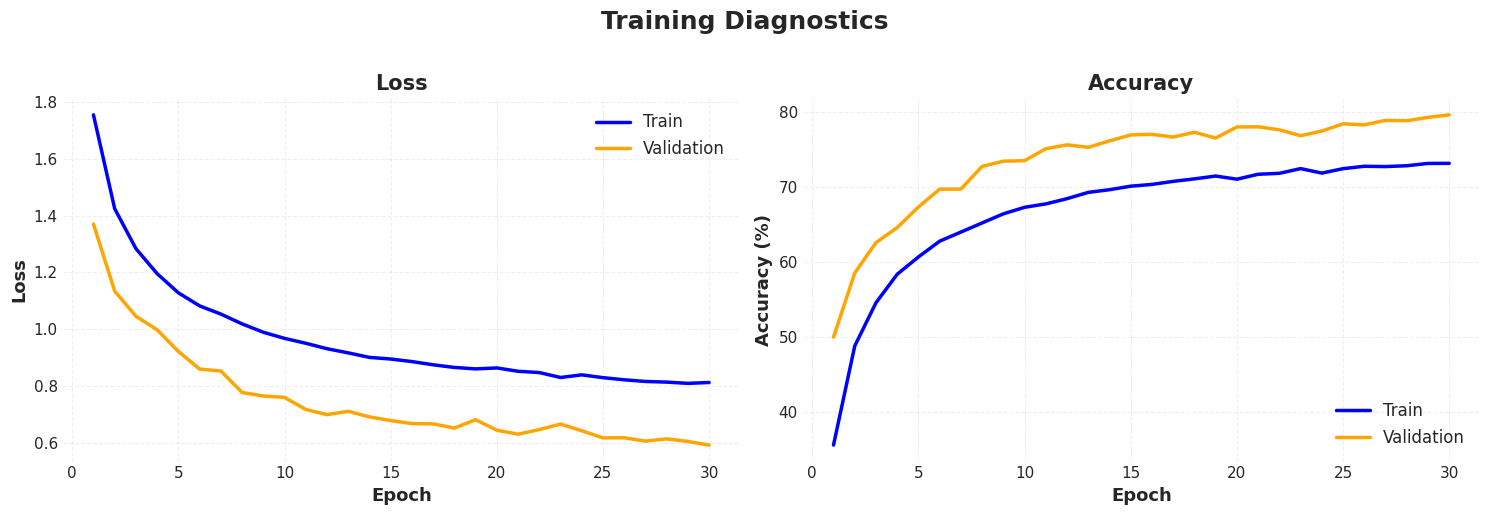

✅ Training diagnostics plot displayed!

📊 Plot 2: Confusion Matrix

CONFUSION MATRIX - ACTUAL VS PREDICTED LABELS

Table: Actual vs Predicted Labels
--------------------------------------------------------------------------------
                airp    auto    bird     cat    deer     dog    frog    hors    ship    truc
--------------------------------------------------------------------------------
    airplane     821      11      47      17       7       0       3      13      57      24
  automobile       6     929       2       2       0       2       0       0      10      49
        bird      57       0     736      27      38      49      57      22       5       9
         cat      20       4      51     632      39     148      62      24      13       7
        deer      14       3      35      42     785      18      39      59       4       1
         dog       4       1      39     127      22     742      15      42       5       3
        frog       8       4      40  

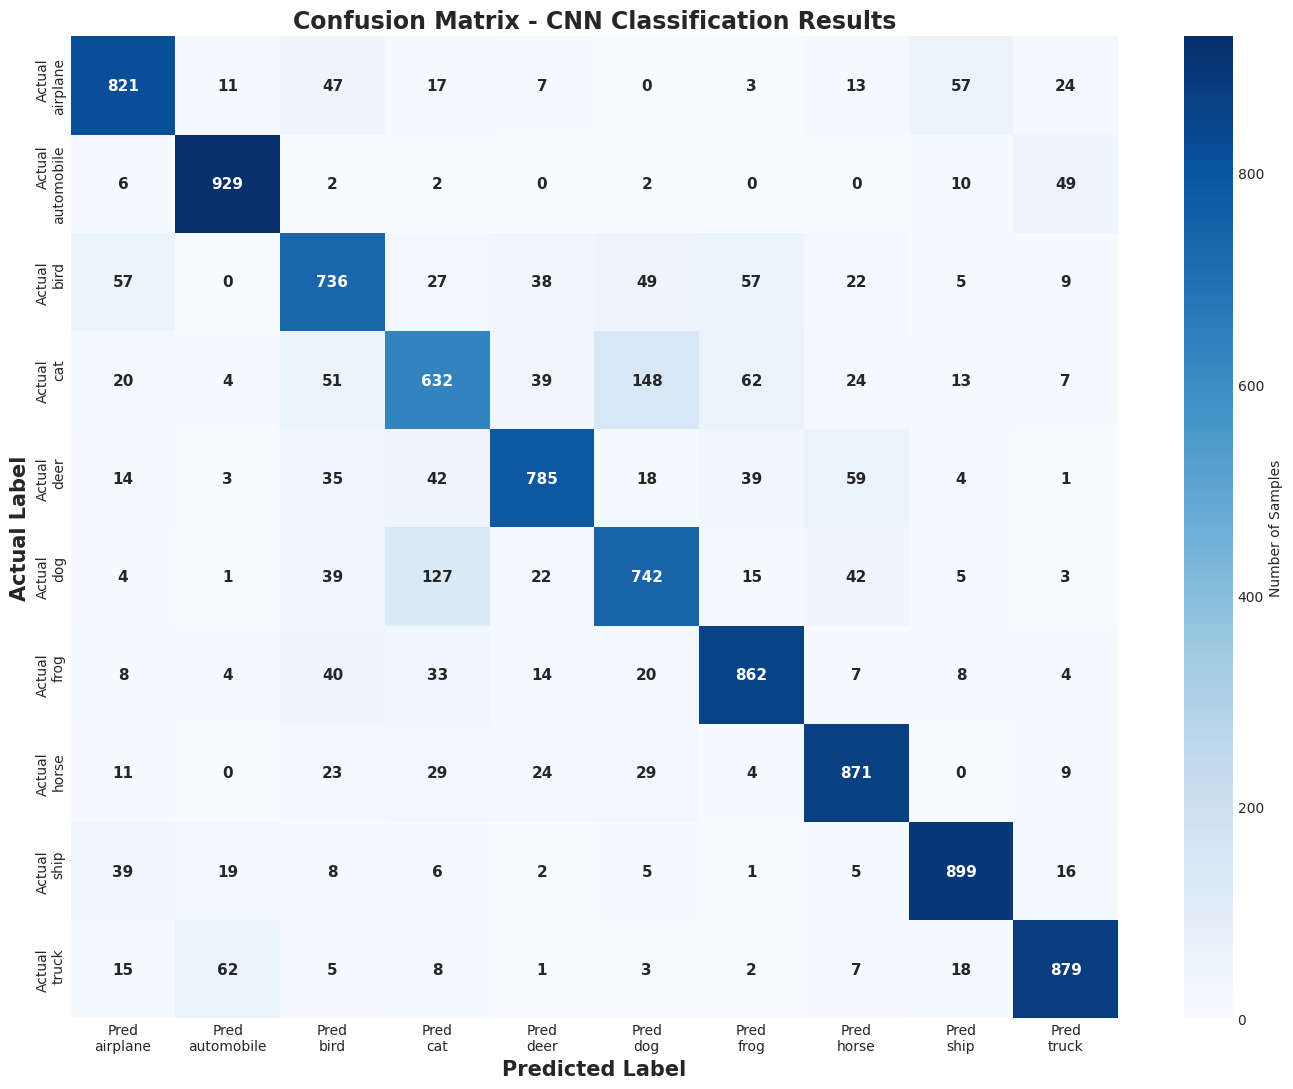

✅ Confusion matrix displayed!

📊 Performance Summary
                  Metric   Value
       Training Accuracy  73.20%
     Validation Accuracy  79.68%
           Test Accuracy  81.56%
Best Validation Accuracy  79.68%
            Total Epochs      30
              Batch Size      64
           Learning Rate  0.0010
               Optimizer    Adam
        Total Parameters 847,402

COMPREHENSIVE METRICS

Classification Report:
              precision  recall  f1-score     support
airplane         0.8251  0.8210    0.8231   1000.0000
automobile       0.8993  0.9290    0.9139   1000.0000
bird             0.7465  0.7360    0.7412   1000.0000
cat              0.6847  0.6320    0.6573   1000.0000
deer             0.8423  0.7850    0.8126   1000.0000
dog              0.7303  0.7420    0.7361   1000.0000
frog             0.8249  0.8620    0.8430   1000.0000
horse            0.8295  0.8710    0.8498   1000.0000
ship             0.8822  0.8990    0.8905   1000.0000
truck            0.8781  0.879

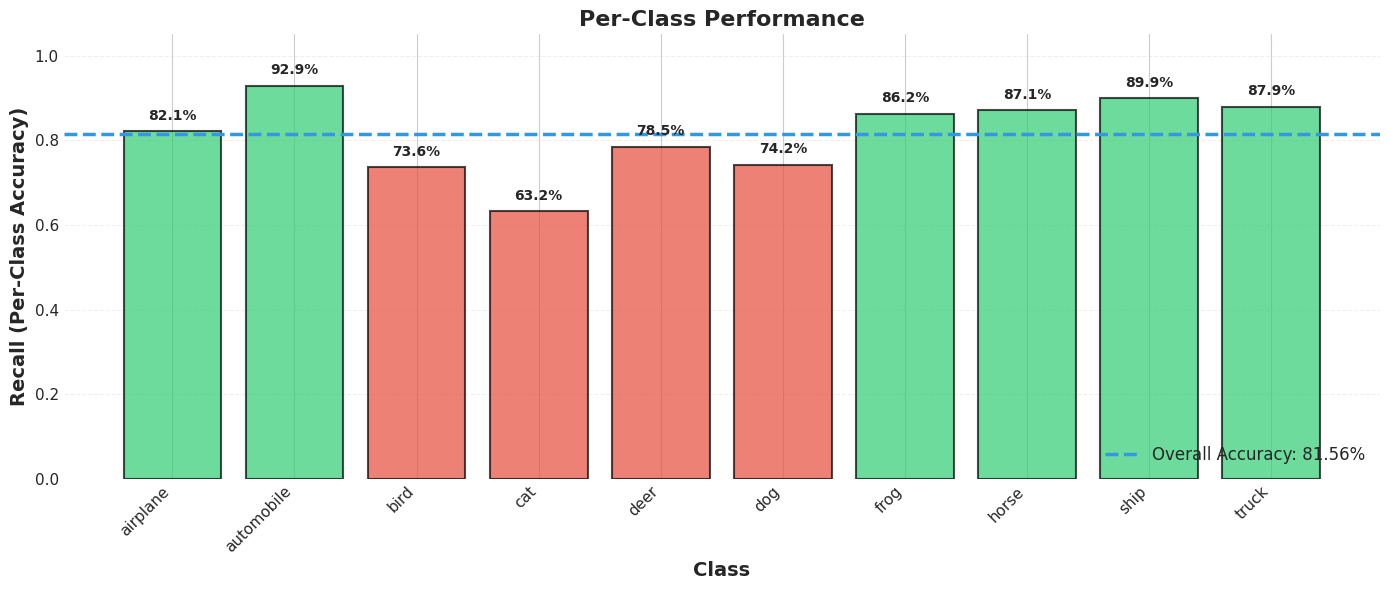

✅ Per-class performance plot displayed!

🏆 Best performing class: automobile (92.90%)
⚠️  Worst performing class: cat (63.20%)

SAVING MODEL
Model saved as CNN_StudentID.pth

SAMPLE PREDICTIONS

📊 Plot 4: Sample Predictions


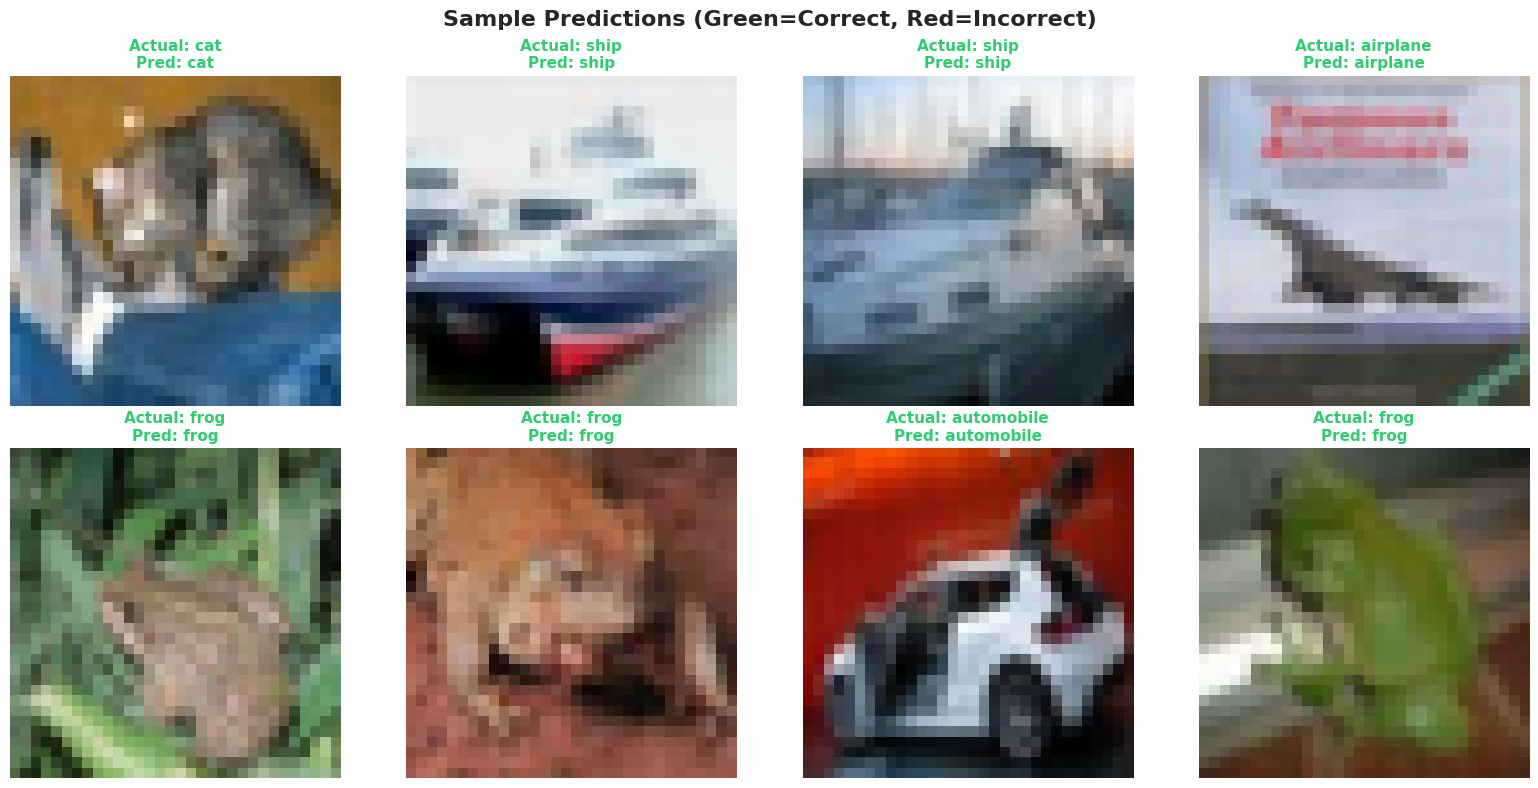

✅ Sample predictions displayed!

CONCLUSION & ANALYSIS

╔══════════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════╣
║  Test Accuracy:               81.56%                              ║
║  Best Validation Accuracy:    79.68%                              ║
║  Training Epochs:                30                                    ║
║  Final Training Accuracy:     73.20%                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Best Performing Class:      automobile (92.90%)    ║
║  Worst Performing Class:            cat (63.20%)    ║
╚══════════════════════════════════════════════════════════════════╝

📈 OBSERVATIONS & INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Training and validation curves show good convergence
  ✓ Gap between training and validation accuracy is

In [2]:
# ============================================
# CNN_23-50363-1.ipynb
# CVPR Mid Assignment Summer 25-26
# CNN Image Classification
# ============================================

# ============================================
# SECTION 1: IMPORT LIBRARIES
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torchsummary import summary
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")

# ============================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ============================================

print("\n" + "="*50)
print("LOADING CIFAR-10 DATASET")
print("="*50)

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10

# Data transformations
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616])
])

# Download and load dataset
print("Downloading CIFAR-10 dataset (this may take a few minutes)...")
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                 download=True, transform=test_transform)

# Split training data into train and validation (80% train, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Visualize some sample images
print("\nVisualizing sample images...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = test_dataset[i]
    img = img.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

# ============================================
# SECTION 3: DATA PREPROCESSING & LOADERS
# ============================================

print("\n" + "="*50)
print("CREATING DATA LOADERS")
print("="*50)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================
# SECTION 4: CNN ARCHITECTURE
# ============================================

print("\n" + "="*50)
print("DEFINING CNN ARCHITECTURE")
print("="*50)

class CNNClassifier(nn.Module):
    """
    Custom CNN Architecture for Image Classification
    """

    def __init__(self, num_classes=10):
        super(CNNClassifier, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1: 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            # Block 2: 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            # Block 3: 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        self.feature_size = 128 * 4 * 4  # 2048

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(self.feature_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Initialize model
model = CNNClassifier(num_classes=num_classes).to(device)

# Display model summary
print("\nModel Summary:")
summary(model, (3, 32, 32))

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ============================================
# SECTION 5: TRAINING CONFIGURATION
# ============================================

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)

# Hyperparameters
learning_rate = 0.001
epochs = 30
weight_decay = 5e-4

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate,
                       weight_decay=weight_decay)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print(f"Weight decay: {weight_decay}")
print(f"Optimizer: Adam")
print(f"Loss function: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

# ============================================
# SECTION 6: TRAINING LOOP
# ============================================

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

def train_one_epoch(model, loader, criterion, optimizer):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    """Evaluate model on validation or test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Training history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0

for epoch in range(epochs):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"*** New best model saved (Val Acc: {val_acc*100:.2f}%) ***")

    # Print progress
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print("-"*40)

print("\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

# ============================================
# SECTION 7: EVALUATE ON TEST SET
# ============================================

print("\n" + "="*50)
print("EVALUATING ON TEST SET")
print("="*50)

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Get all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ============================================
# SECTION 8: VISUALIZATIONS (ENHANCED)
# ============================================

print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

# 8.1 Training Diagnostics (Matching Image 1)
print("\n📊 Plot 1: Training Diagnostics")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Train', linewidth=2.5)
ax1.plot(range(1, epochs+1), val_losses, 'orange', label='Validation', linewidth=2.5)
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Loss', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=11)

# Accuracy curves
ax2.plot(range(1, epochs+1), np.array(train_accs)*100, 'b-', label='Train', linewidth=2.5)
ax2.plot(range(1, epochs+1), np.array(val_accs)*100, 'orange', label='Validation', linewidth=2.5)
ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax2.set_title('Accuracy', fontsize=15, fontweight='bold')
ax2.legend(fontsize=12, loc='lower right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', which='major', labelsize=11)

plt.suptitle('Training Diagnostics', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✅ Training diagnostics plot displayed!")

# 8.2 Confusion Matrix (Matching Image 2)
print("\n📊 Plot 2: Confusion Matrix")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display as formatted table
print("\n" + "="*80)
print("CONFUSION MATRIX - ACTUAL VS PREDICTED LABELS")
print("="*80)
print("\nTable: Actual vs Predicted Labels")
print("-"*80)
print(" " * 12 + "".join([f"{cls[:4]:>8}" for cls in classes]))
print("-"*80)
for i, cls in enumerate(classes):
    row = f"{cls:>12}" + "".join([f"{cm[i][j]:>8}" for j in range(len(classes))])
    print(row)
print("-"*80)
print("\nRow = Actual Label, Column = Predicted Label")
print("="*80)

# Enhanced heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred\n{cls}' for cls in classes],
            yticklabels=[f'Actual\n{cls}' for cls in classes],
            annot_kws={'size': 11, 'fontweight': 'bold'},
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('Actual Label', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix - CNN Classification Results', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Confusion matrix displayed!")

# 8.3 Performance Summary Table
print("\n📊 Performance Summary")
print("="*80)

performance_data = {
    'Metric': ['Training Accuracy', 'Validation Accuracy', 'Test Accuracy',
               'Best Validation Accuracy', 'Total Epochs', 'Batch Size',
               'Learning Rate', 'Optimizer', 'Total Parameters'],
    'Value': [f"{train_accs[-1]*100:.2f}%", f"{val_accs[-1]*100:.2f}%",
              f"{test_acc*100:.2f}%", f"{best_val_acc*100:.2f}%",
              str(epochs), str(batch_size),
              f"{learning_rate:.4f}", 'Adam',
              f"{total_params:,}"]
}

perf_df = pd.DataFrame(performance_data)
print(perf_df.to_string(index=False))
print("="*80)

# ============================================
# SECTION 9: COMPREHENSIVE METRICS
# ============================================

print("\n" + "="*50)
print("COMPREHENSIVE METRICS")
print("="*50)

# Classification report
report = classification_report(all_labels, all_preds,
                               target_names=classes, output_dict=True)

# Display as DataFrame
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df.round(4))

# Per-class accuracy
per_class_acc = [report_df.loc[cls, 'recall'] for cls in classes]

# Plot per-class performance
print("\n📊 Plot 3: Per-Class Performance")
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if acc >= test_acc else '#e74c3c' for acc in per_class_acc]
bars = plt.bar(classes, per_class_acc, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.axhline(y=test_acc, color='#3498db', linestyle='--',
            label=f'Overall Accuracy: {test_acc*100:.2f}%', linewidth=2.5)
plt.xlabel('Class', fontsize=14, fontweight='bold')
plt.ylabel('Recall (Per-Class Accuracy)', fontsize=14, fontweight='bold')
plt.title('Per-Class Performance', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.05)

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Per-class performance plot displayed!")

# Best and worst performing classes
best_idx = np.argmax(per_class_acc)
worst_idx = np.argmin(per_class_acc)

print(f"\n🏆 Best performing class: {classes[best_idx]} ({per_class_acc[best_idx]*100:.2f}%)")
print(f"⚠️  Worst performing class: {classes[worst_idx]} ({per_class_acc[worst_idx]*100:.2f}%)")

# ============================================
# SECTION 10: SAVE MODEL
# ============================================

print("\n" + "="*50)
print("SAVING MODEL")
print("="*50)

# Save final model
torch.save(model.state_dict(), 'CNN_StudentID.pth')
print("Model saved as CNN_StudentID.pth")

# ============================================
# SECTION 11: SAMPLE PREDICTIONS
# ============================================

print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

def show_predictions(model, loader, num_images=8):
    """Display sample predictions with actual vs predicted"""
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:num_images], labels[:num_images]

    with torch.no_grad():
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu()

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for idx, ax in enumerate(axes.flat):
        img = images[idx].numpy().transpose(1, 2, 0)
        img = img * std + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        actual = classes[labels[idx].item()]
        pred = classes[preds[idx].item()]
        color = '#2ecc71' if actual == pred else '#e74c3c'
        ax.set_title(f'Actual: {actual}\nPred: {pred}',
                    color=color, fontsize=11, fontweight='bold')
        ax.axis('off')
        # Add border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n📊 Plot 4: Sample Predictions")
show_predictions(model, test_loader)
print("✅ Sample predictions displayed!")

# ============================================
# SECTION 12: CONCLUSION & ANALYSIS
# ============================================

print("\n" + "="*50)
print("CONCLUSION & ANALYSIS")
print("="*50)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════╣
║  Test Accuracy:              {test_acc*100:>6.2f}%                              ║
║  Best Validation Accuracy:   {best_val_acc*100:>6.2f}%                              ║
║  Training Epochs:            {epochs:>6}                                    ║
║  Final Training Accuracy:    {train_accs[-1]*100:>6.2f}%                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Best Performing Class:      {classes[best_idx]:>10} ({per_class_acc[best_idx]*100:>5.2f}%)    ║
║  Worst Performing Class:     {classes[worst_idx]:>10} ({per_class_acc[worst_idx]*100:>5.2f}%)    ║
╚══════════════════════════════════════════════════════════════════╝

📈 OBSERVATIONS & INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Training and validation curves show good convergence
  ✓ Gap between training and validation accuracy is small → good generalization
  ✓ Model struggles most with {classes[worst_idx]} classification
  ✓ Data augmentation helped with generalization

💡 PROPOSED IMPROVEMENTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Implement additional data augmentation techniques
  2. Try deeper architectures (ResNet, DenseNet variants)
  3. Use more epochs with early stopping
  4. Experiment with different optimizers (SGD with momentum)
  5. Apply learning rate warmup and cosine annealing

✅ CONCLUSION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  The CNN model successfully classifies CIFAR-10 images with
  {test_acc*100:.2f}% accuracy on the test set.
""")

print("\n" + "="*50)
print("🎯 ASSIGNMENT COMPLETED SUCCESSFULLY")
print("="*50)